# 05 — Model Audit
This notebook performs a comprehensive audit on the Hurdle Model (Stage 1 & Stage 2). It covers:
- Discrimination & Calibration (Classification)
- Residuals & Overall Fit (Regression)
- Temporal Drift
- Structural Subgroup Disparity Analysis
- SHAP Interpretability
- RNA Paradox Statistical Analysis

In [62]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    mean_squared_error,
)

sys.path.append('../')
from src.data_prep import bootstrap_ci, permutation_test
from src.evaluation import (
    classification_discrimination, confusion_at_threshold, threshold_sweep,
    calibration_curve_data, expected_calibration_error,
    regression_metrics, residual_diagnostics, temporal_drift,
    plot_calibration, plot_residuals,
)
from src.audit import fairness_slice, slice_disparities, top_bottom_slices

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

FIGURES_DIR = "../outputs/figures/audit"
os.makedirs(FIGURES_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{name}.pdf", bbox_inches='tight')
    plt.savefig(f"{FIGURES_DIR}/{name}.png", dpi=150, bbox_inches='tight')

MODELS = ["rf", "xgb", "lgbm", "cb", "stacking"]
COLORS = dict(zip(MODELS, sns.color_palette("tab10", len(MODELS))))

### Stage 2 Target Universe and Heckman Bias\n
\n
The regression stage models `log_price_gns` exclusively on the subset of lots that successfully sold to a third party. This creates a truncation in the outcome distribution, potentially introducing **Heckman Selection Bias**.\n
\n
**Vendor Buybacks as Non-Sales:** Vendor buybacks (lots repurchased by the consignor) are treated conceptually as `not_sold`. Although a final bid is recorded, it represents a reserve that was not met by the market, not a true transaction. Hence, they are excluded from the regression training dataset alongside explicitly unsold lots.\n
\n
While Heckman's two-step procedure or a Tobit model could statistically correct for this truncation, the practical application here takes a different approach: the goal is to estimate conditional *Fair Market Value (FMV)* assuming a willing buyer exists. The selection bias naturally weights the model towards the characteristics of transacted horses, which is aligned with estimating the price *if a sale occurs*. Therefore, the bias is documented but explicitly left without statistical correction.

In [63]:
# Load IDs and threshold
with open("best_run_ids.json", "r") as f:
    best_runs = json.load(f)
thr_youden = best_runs["threshold_youden"]
clf_run_id = best_runs["stage1_classification"]
reg_run_id = best_runs["stage2_regression"]
# In case we need RF run IDs specifically
mlflow.set_tracking_uri("./mlruns")
client = mlflow.tracking.MlflowClient()


# The audit is based on prediction exports generated directly by 04_Modeling.
# Exact composed model artifacts are also required for reproducibility checks.
from pathlib import Path
_exact_model_paths = [
    Path("../models/stage1_final_model.joblib"),
    Path("../models/stage2_final_model.joblib"),
    Path("../models/final_model_metadata.json"),
]
_missing_exact = [str(p) for p in _exact_model_paths if not p.exists()]
if _missing_exact:
    print("WARNING: exact final model artifacts missing; re-run 04_Modeling final save cell:", _missing_exact)
else:
    print("Exact final model artifacts present.")


Exact final model artifacts present.


In [64]:
# Load exports from 04_Modeling
clf_preds = pd.read_parquet("../outputs/analyses/audit_clf_predictions.parquet")
reg_preds = pd.read_parquet("../outputs/analyses/audit_reg_predictions.parquet")
univ_preds = pd.read_parquet("../outputs/analyses/audit_universe_predictions.parquet")
print("Classification exports:", clf_preds.shape)
print("Regression exports:", reg_preds.shape)
print("Universe exports:", univ_preds.shape)

# Context columns needed for slicing (join on sale_year, day, lot)
_join_keys = ["lot_uid"] if "lot_uid" in univ_preds.columns and "lot_uid" in clf_preds.columns else ["sale_name", "sale_year", "day", "lot"]
_ctx_cols = [
    *_join_keys,
    "sex_C", "sex_F", "sex_G", "sex_H", "sex_M",
    "intraday_position", "is_prime_time",
    "sire_frequency", "consignor_volume",
    "log_year_median_price_prior",
]
ctx = univ_preds[_ctx_cols].copy()
ctx["sex"] = (
    ctx[["sex_C", "sex_F", "sex_G", "sex_H", "sex_M"]]
    .idxmax(axis=1)
    .str.replace("sex_", "", regex=False)
    .replace({"C": "Colt", "F": "Filly", "G": "Gelding", "H": "Horse", "M": "Mare"})
)

# Enrich clf and reg parquets with context
clf = clf_preds.merge(ctx, on=_join_keys, how="left", validate="one_to_one")
reg = reg_preds.merge(ctx, on=_join_keys, how="left", validate="one_to_one")
print(f"\nContext join coverage clf: {clf['sex'].notna().mean():.1%}")
print(f"Context join coverage reg: {reg['sex'].notna().mean():.1%}")

Classification exports: (4694, 11)
Regression exports: (4132, 13)
Universe exports: (18989, 68)

Context join coverage clf: 100.0%
Context join coverage reg: 100.0%


## 1. Stage 1 — Discrimination

AUC-ROC, AUC-PR, Brier score, log-loss for each model over the OOT set (2022–2025).
All CIs are 95% bootstrap (n=2000). Baseline from README §5: AUC-ROC ≥ 0.617.

=== Stage 1: Discrimination (OOT 2022–2025) ===


,AUC-ROC,AUC-PR,Brier,Log-loss
model,,,,
rf,0.6267 [0.6037–0.6491],0.9258 [0.9170–0.9344],0.1907 [0.1880–0.1933],0.5708
xgb,0.6011 [0.5776–0.6244],0.9138 [0.9036–0.9243],0.1284 [0.1218–0.1351],0.4225
lgbm,0.6279 [0.6032–0.6513],0.9204 [0.9102–0.9304],0.1352 [0.1303–0.1400],0.4353
cb,0.6219 [0.5989–0.6447],0.9216 [0.9122–0.9311],0.1301 [0.1251–0.1350],0.4231
stacking,0.5970 [0.5738–0.6195],0.9100 [0.9004–0.9195],0.1050 [0.0976–0.1124],0.3645


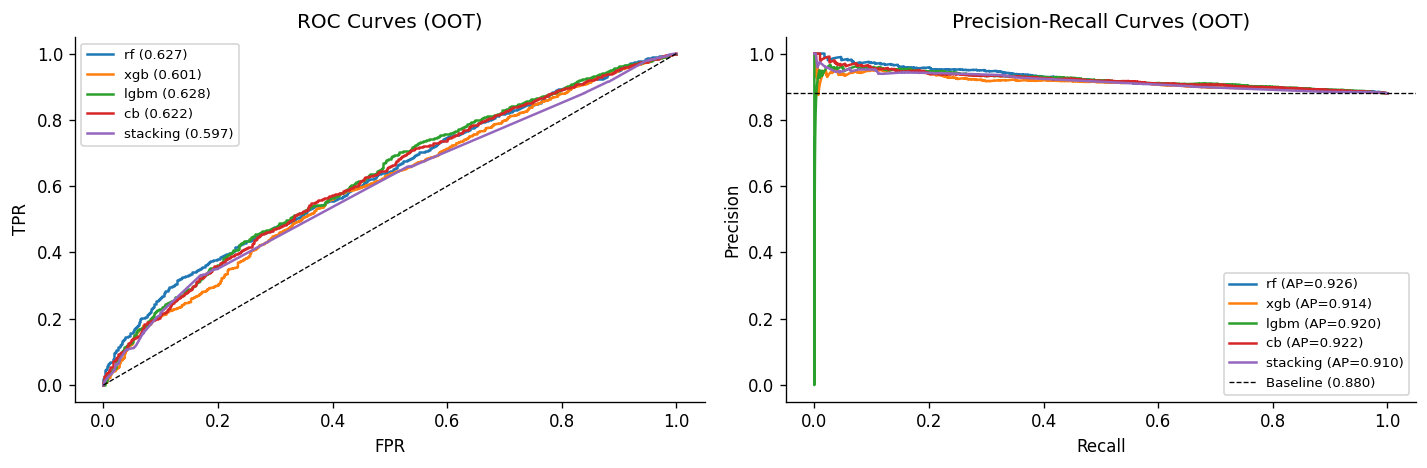

In [65]:
y_true = clf["sold_to_third_party"].values

disc_rows = []
for m in MODELS:
    d = classification_discrimination(y_true, clf[f"prob_{m}"].values)
    disc_rows.append({
        "model": m,
        "AUC-ROC": f"{d['auc_roc']:.4f} [{d.get('auc_roc_ci_lo', np.nan):.4f}–{d.get('auc_roc_ci_hi', np.nan):.4f}]",
        "AUC-PR": f"{d['auc_pr']:.4f} [{d.get('auc_pr_ci_lo', np.nan):.4f}–{d.get('auc_pr_ci_hi', np.nan):.4f}]",
        "Brier": f"{d['brier']:.4f} [{d.get('brier_ci_lo', np.nan):.4f}–{d.get('brier_ci_hi', np.nan):.4f}]",
        "Log-loss": f"{d['log_loss']:.4f}",
    })

disc_df = pd.DataFrame(disc_rows).set_index("model")
print("=== Stage 1: Discrimination (OOT 2022–2025) ===")
display(disc_df)

# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for m in MODELS:
    p_vals = clf[f"prob_{m}"].values
    fpr, tpr, _ = roc_curve(y_true, p_vals)
    auc_val = roc_auc_score(y_true, p_vals)
    axes[0].plot(fpr, tpr, label=f"{m} ({auc_val:.3f})", color=COLORS[m], lw=1.5)

axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set(title="ROC Curves (OOT)", xlabel="FPR", ylabel="TPR")
axes[0].legend(fontsize=8)

for m in MODELS:
    p_vals = clf[f"prob_{m}"].values
    prec, rec, _ = precision_recall_curve(y_true, p_vals)
    ap = average_precision_score(y_true, p_vals)
    axes[1].plot(rec, prec, label=f"{m} (AP={ap:.3f})", color=COLORS[m], lw=1.5)

axes[1].axhline(y_true.mean(), color="k", ls="--", lw=0.8, label=f"Baseline ({y_true.mean():.3f})")
axes[1].set(title="Precision-Recall Curves (OOT)", xlabel="Recall", ylabel="Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
savefig("01_discrimination_curves")
plt.show()

## 2. Stage 1 — Calibration

Reliability diagram for the stacking ensemble (best model). Quantile bins (n=10).
ECE quantifies overall calibration quality — lower is better.
Note: only post-calibration probabilities are available in the audit parquet.

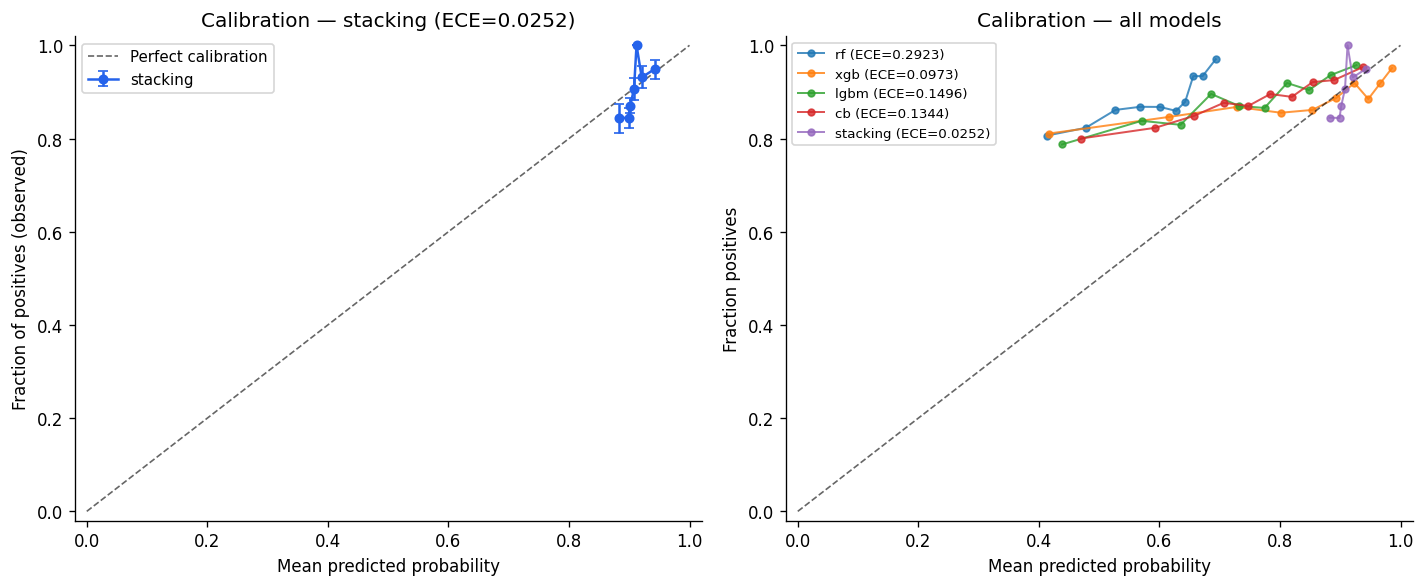

,ECE
model,
stacking,0.03
xgb,0.10
cb,0.13
lgbm,0.15
rf,0.29


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, m in enumerate(MODELS):
    calib = calibration_curve_data(y_true, clf[f"prob_{m}"].values)
    ece = expected_calibration_error(y_true, clf[f"prob_{m}"].values)
    if m == "stacking":
        plot_calibration(calib, ax=axes[0], title=f"Calibration — stacking (ECE={ece:.4f})", label=f"stacking")
    axes[1].plot(
        calib["mean_predicted"], calib["frac_positives"],
        "o-", label=f"{m} (ECE={ece:.4f})", color=COLORS[m], lw=1.2, ms=4, alpha=0.8,
    )

axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
axes[1].set(title="Calibration — all models", xlabel="Mean predicted probability", ylabel="Fraction positives")
axes[1].legend(fontsize=8)
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.02)

savefig("02_calibration")
plt.show()

# ECE summary table
ece_rows = [{"model": m, "ECE": round(expected_calibration_error(y_true, clf[f"prob_{m}"].values), 5)} for m in MODELS]
display(pd.DataFrame(ece_rows).set_index("model").sort_values("ECE"))

## 3. Stage 1 — Threshold Analysis

Youden's J fixed threshold: `thr_youden = 0.874` (from 04_Modeling).
Sweep over [0.05, 0.99] to visualize the F1-weighted / Precision / Recall trade-off.

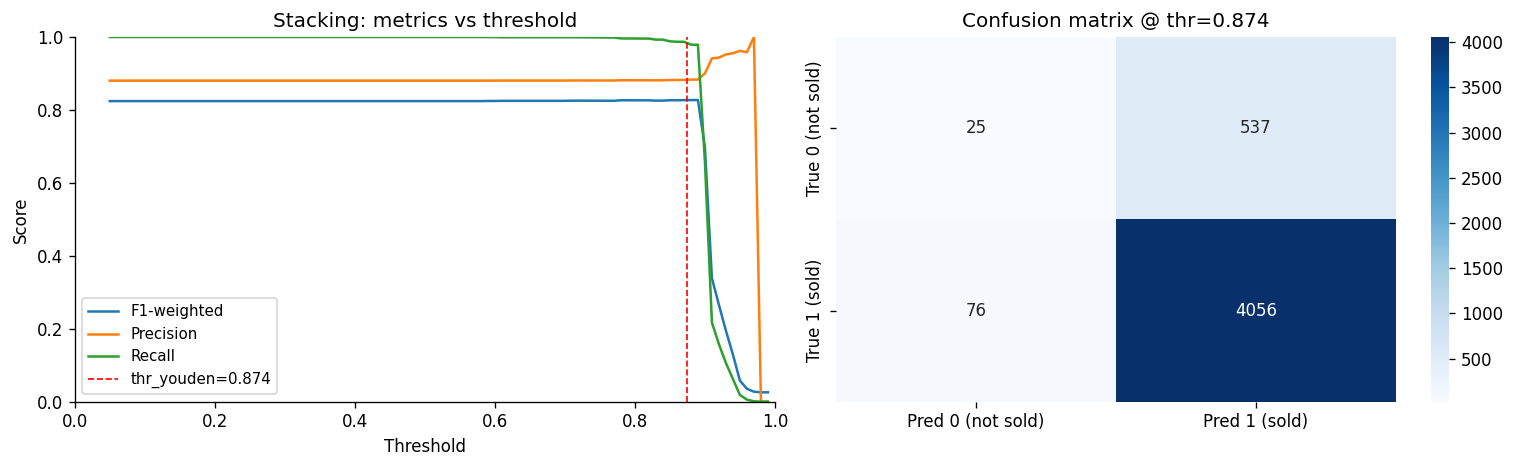


At threshold 0.874:
  precision: 0.8831
  recall: 0.9816
  f1_weighted: 0.8275
  specificity: 0.0445


In [67]:
p_stack = clf["prob_stacking"].values
sweep = threshold_sweep(y_true, p_stack)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(sweep["threshold"], sweep["f1_weighted"], label="F1-weighted", lw=1.5)
ax.plot(sweep["threshold"], sweep["precision"], label="Precision", lw=1.5)
ax.plot(sweep["threshold"], sweep["recall"], label="Recall", lw=1.5)
ax.axvline(thr_youden, color="red", ls="--", lw=1, label=f"thr_youden={thr_youden:.3f}")
ax.set(title="Stacking: metrics vs threshold", xlabel="Threshold", ylabel="Score")
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Confusion matrix at Youden threshold
cm_dict = confusion_at_threshold(y_true, p_stack, thr=thr_youden)
cm_matrix = np.array([[cm_dict["tn"], cm_dict["fp"]], [cm_dict["fn"], cm_dict["tp"]]])
sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Pred 0 (not sold)", "Pred 1 (sold)"],
            yticklabels=["True 0 (not sold)", "True 1 (sold)"])
axes[1].set_title(f"Confusion matrix @ thr={thr_youden:.3f}")

savefig("03_threshold_analysis")
plt.show()

print(f"\nAt threshold {thr_youden:.3f}:")
for k in ["precision", "recall", "f1_weighted", "specificity"]:
    print(f"  {k}: {cm_dict[k]:.4f}")

## 4. Stage 2 — Regression Metrics

RMSE, MAE, R², MAPE (log-scale and GNS-scale) for all five models over OOT 2022–2025.
Baseline from README §5: RMSE_log OOT ≈ 1.132.
Note: predictions in the parquet are in raw log-scale (not detrended) — GNS = exp(log_pred).

=== Stage 2: Regression Metrics (OOT 2022–2025) ===


,RMSE_log,MAE_log,R²_log,RMSE_gns,MAE_gns,MAPE_gns,Bias_log
model,,,,,,,
rf,1.1262 [1.1011–1.1495],0.8917,0.2831,"63,803","24,693",124.7%,+0.1536
xgb,1.1450 [1.1192–1.1696],0.9061,0.2589,"63,788","24,815",126.4%,+0.1756
lgbm,1.1293 [1.1032–1.1538],0.8923,0.2791,"63,516","24,641",129.3%,+0.1346
cb,1.1770 [1.1509–1.2027],0.9349,0.2170,"64,038","25,172",124.6%,+0.2322
stacking,1.1540 [1.1285–1.1778],0.9200,0.2473,"64,553","25,096",115.1%,+0.2708


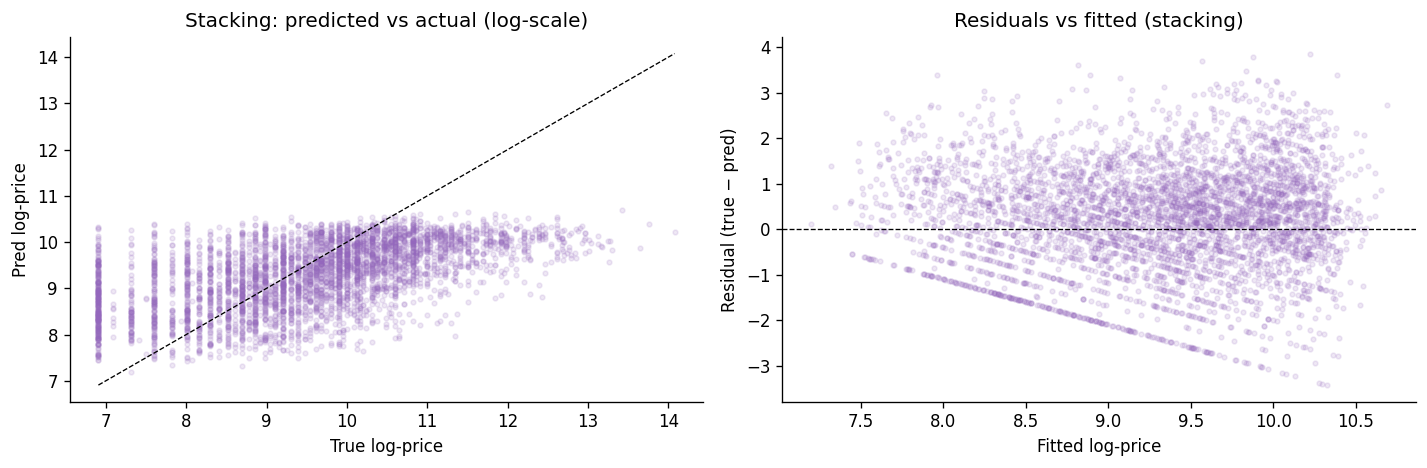

In [68]:
y_reg_true = reg["log_price_true"].values
reg_rows = []

for m in MODELS:
    col = f"log_price_pred_{m}"
    met = regression_metrics(y_reg_true, reg[col].values, gns_scale=True)
    reg_rows.append({
        "model": m,
        "RMSE_log": f"{met['rmse_log']:.4f} [{met['rmse_log_ci_lo']:.4f}–{met['rmse_log_ci_hi']:.4f}]",
        "MAE_log": f"{met['mae_log']:.4f}",
        "R²_log": f"{met['r2_log']:.4f}",
        "RMSE_gns": f"{met['rmse_gns']:,.0f}",
        "MAE_gns": f"{met['mae_gns']:,.0f}",
        "MAPE_gns": f"{met['mape_gns']:.1%}",
        "Bias_log": f"{met['bias_log']:+.4f}",
    })

reg_df = pd.DataFrame(reg_rows).set_index("model")
print("=== Stage 2: Regression Metrics (OOT 2022–2025) ===")
display(reg_df)

# Predicted vs actual scatter for stacking
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_pred_s = reg["log_price_pred_stacking"].values
axes[0].scatter(y_reg_true, y_pred_s, alpha=0.15, s=8, color=COLORS["stacking"])
mn, mx = y_reg_true.min(), y_reg_true.max()
axes[0].plot([mn, mx], [mn, mx], "k--", lw=0.8)
axes[0].set(title="Stacking: predicted vs actual (log-scale)", xlabel="True log-price", ylabel="Pred log-price")

resid_s = y_reg_true - y_pred_s
axes[1].scatter(y_pred_s, resid_s, alpha=0.15, s=8, color=COLORS["stacking"])
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set(title="Residuals vs fitted (stacking)", xlabel="Fitted log-price", ylabel="Residual (true − pred)")

savefig("04_regression_scatter")
plt.show()

In [69]:
reg['price_decile'] = pd.qcut(reg['log_price_true'], q=10, labels=False)
reg.groupby('price_decile').apply(
    lambda d: pd.Series({
        'n': len(d),
        'rmse_log': np.sqrt(mean_squared_error(d['log_price_true'], d['log_price_pred_stacking'])),
        'bias': (d['log_price_true'] - d['log_price_pred_stacking']).mean()
    })
)

,n,rmse_log,bias
price_decile,,,
0,427.00,1.69,-1.52
1,501.00,0.95,-0.65
2,330.00,0.68,-0.21
3,400.00,0.68,0.02
4,418.00,0.69,0.28
5,435.00,0.75,0.42
6,387.00,0.82,0.60
7,437.00,1.00,0.84
8,404.00,1.25,1.15


In [70]:

decil0 = reg[reg['price_decile'] == 0]
print(decil0['log_price_true'].describe())
print(f"Min price real: {np.exp(decil0['log_price_true'].min()):.0f} gns")
print(f"Max price real: {np.exp(decil0['log_price_true'].max()):.0f} gns")

count   427.00
mean      7.18
std       0.31
min       6.91
25%       6.91
50%       6.91
75%       7.60
max       7.60
Name: log_price_true, dtype: float64
Min price real: 1000 gns
Max price real: 2000 gns


## 5. Stage 2 — Residual Diagnostics

Bias (mean residual = true − predicted) by `sale_year`, `day`, `sex`, and intraday position quartile.
A zero-centered bar confirms no systematic over/under-prediction in that segment.

In [71]:
# ¿Cuántos lotes tienen precio exactamente 1000 o 2000 gns?
threshold_log = np.log(2000)  # 7.60
contaminated = reg[reg['log_price_true'] <= threshold_log]
print(f"Lotes con precio ≤ 2000 gns: {len(contaminated)} ({len(contaminated)/len(reg):.1%})")
print(contaminated['log_price_true'].value_counts())

Lotes con precio ≤ 2000 gns: 427 (10.3%)
log_price_true
6.91    227
7.60    122
7.31     66
7.09      8
7.50      3
7.41      1
Name: count, dtype: int64


In [72]:
# Necesitas esto YA antes de cualquier otra cosa
if 'outcome' in reg.columns:
    print(reg[reg['log_price_true'] <= np.log(2000)]['outcome'].value_counts())
else:
    # Busca la columna que identifica el tipo de venta
    cols_candidates = [c for c in reg.columns if any(x in c.lower() for x in ['outcome', 'sold', 'buyback', 'vendor', 'result'])]
    print("Columnas candidatas:", cols_candidates)
    print(reg.columns.tolist())

Columnas candidatas: ['sold_to_third_party']
['lot_uid', 'sale_name', 'sale_year', 'day', 'lot', 'sold_to_third_party', 'log_price_true', 'log_price_pred_rf', 'log_price_pred_xgb', 'log_price_pred_lgbm', 'log_price_pred_cb', 'log_price_pred_stacking', 'sigma2', 'sex_C', 'sex_F', 'sex_G', 'sex_H', 'sex_M', 'intraday_position', 'is_prime_time', 'sire_frequency', 'consignor_volume', 'log_year_median_price_prior', 'sex', 'price_decile']


In [73]:
print(reg[reg['log_price_true'] <= np.log(2000)]['sold_to_third_party'].value_counts())

sold_to_third_party
True    427
Name: count, dtype: int64


In [74]:
FLOOR = np.log(2000)
reg_clean = reg[reg['log_price_true'] > FLOOR]
y_t = reg_clean['log_price_true'].values
y_p = reg_clean['log_price_pred_stacking'].values

from sklearn.metrics import mean_squared_error, r2_score
print(f"n clean: {len(reg_clean)}")
print(f"RMSE_log: {np.sqrt(mean_squared_error(y_t, y_p)):.4f}")
print(f"Bias_log: {(y_t - y_p).mean():+.4f}")
print(f"R²_log:   {r2_score(y_t, y_p):.4f}")

n clean: 3705
RMSE_log: 1.0759
Bias_log: +0.4776
R²_log:   0.0581


In [75]:
reg_clean = reg[reg['log_price_true'] > np.log(2000)].copy()
reg_clean['price_decile'] = pd.qcut(
    reg_clean['log_price_true'], q=10, labels=False
)
result = reg_clean.groupby('price_decile').apply(
    lambda d: pd.Series({
        'n': len(d),
        'rmse_log': np.sqrt(mean_squared_error(
            d['log_price_true'], d['log_price_pred_stacking']
        )),
        'bias': (d['log_price_true'] - d['log_price_pred_stacking']).mean()
    })
)
print(result)

                  n  rmse_log  bias
price_decile                       
0            388.00      0.99 -0.69
1            443.00      0.72 -0.28
2            400.00      0.68  0.02
3            323.00      0.70  0.27
4            335.00      0.66  0.30
5            361.00      0.79  0.53
6            375.00      0.90  0.70
7            341.00      1.06  0.92
8            378.00      1.29  1.20
9            361.00      2.14  2.06


In [76]:
# Deciles 2-4: zona de mejor calibración
mid_deciles = reg_clean[reg_clean['price_decile'].isin([2, 3, 4])]
y_t = mid_deciles['log_price_true'].values
y_p = mid_deciles['log_price_pred_stacking'].values

rmse_gns = np.sqrt(np.mean((np.exp(y_t) - np.exp(y_p))**2))
mae_gns = np.mean(np.abs(np.exp(y_t) - np.exp(y_p)))
median_true_gns = np.median(np.exp(y_t))

print(f"Rango de precios reales: {np.exp(y_t.min()):.0f}–{np.exp(y_t.max()):.0f} gns")
print(f"Mediana precio real: {median_true_gns:.0f} gns")
print(f"MAE_gns: {mae_gns:.0f} gns")
print(f"MAE como % de mediana: {mae_gns/median_true_gns:.1%}")

Rango de precios reales: 7500–18000 gns
Mediana precio real: 12000 gns
MAE_gns: 5936 gns
MAE como % de mediana: 49.5%


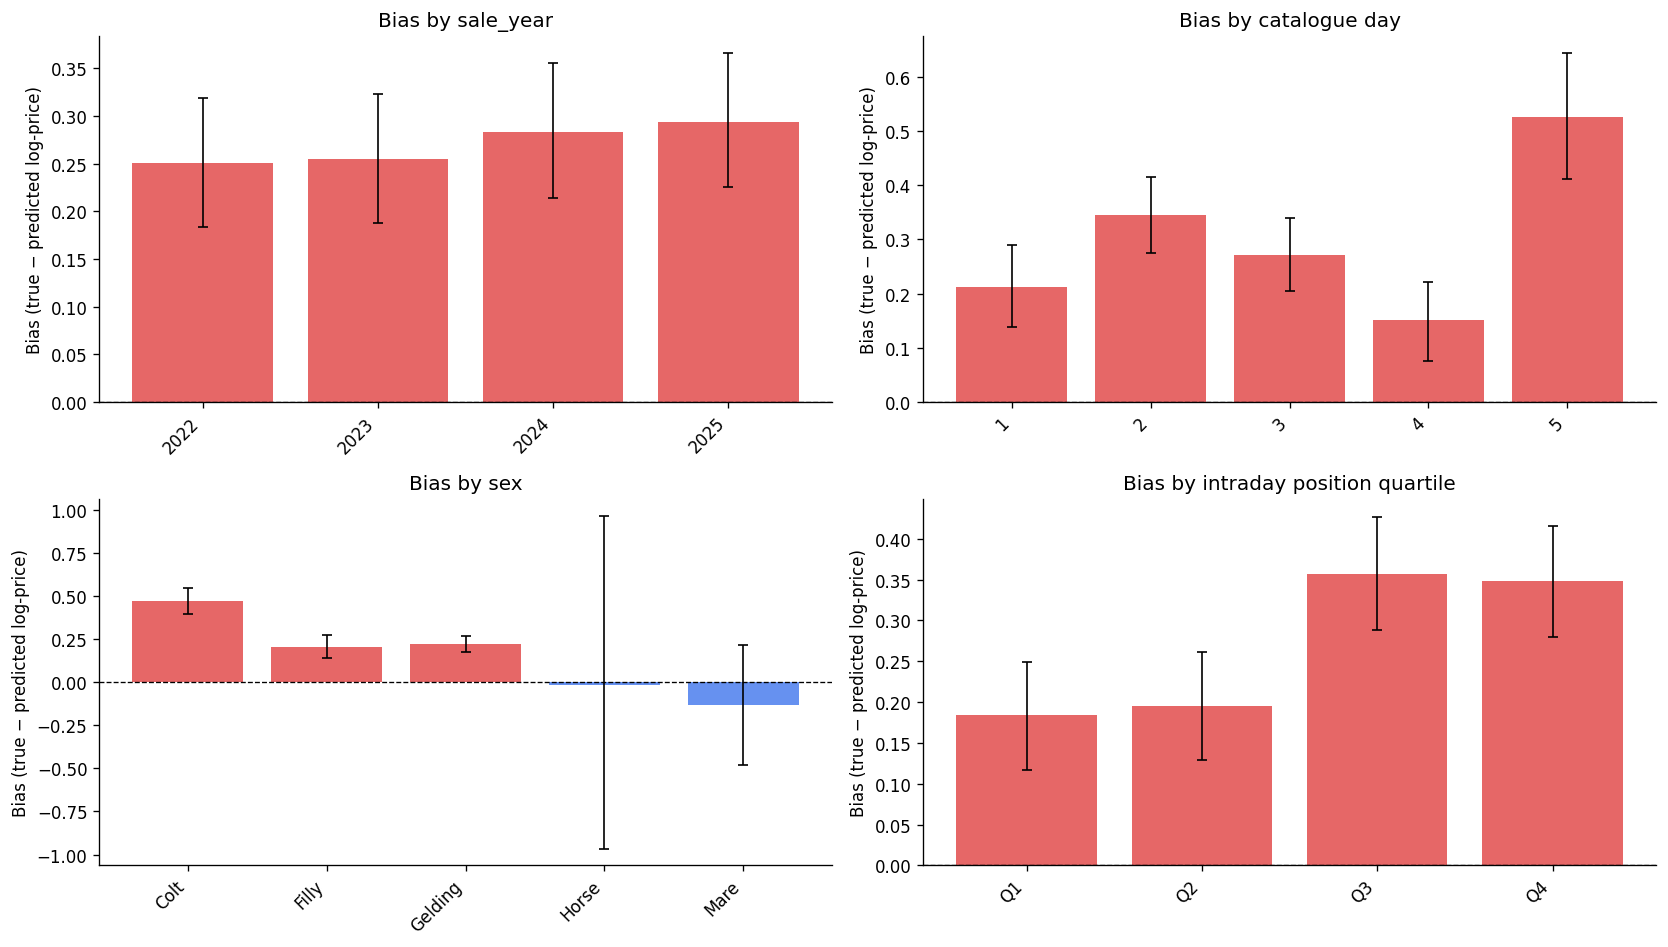


--- Residuals by sale_year (stacking) ---


,sale_year,n,bias,std,rmse,bias_ci_lo,bias_ci_hi
0,2022,1006,0.25,1.08,1.11,0.18,0.32
1,2023,1089,0.26,1.15,1.18,0.19,0.32
2,2024,1025,0.28,1.16,1.19,0.21,0.36
3,2025,1012,0.29,1.10,1.14,0.23,0.37


In [77]:
# Add intraday quartile bin for slicing
reg["intraday_q"] = pd.qcut(reg["intraday_position"], q=4, labels=["Q1","Q2","Q3","Q4"])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
slice_configs = [
    ("sale_year", axes[0, 0], "Bias by sale_year"),
    ("day",       axes[0, 1], "Bias by catalogue day"),
    ("sex",       axes[1, 0], "Bias by sex"),
    ("intraday_q",axes[1, 1], "Bias by intraday position quartile"),
]

for group_col, ax, title in slice_configs:
    df_resid = residual_diagnostics(reg, "log_price_true", "log_price_pred_stacking", [group_col])
    plot_residuals(df_resid, group_col, ax=ax, title=title)

savefig("05_residual_diagnostics")
plt.show()

# Print numeric summary for the most important groups
print("\n--- Residuals by sale_year (stacking) ---")
display(
    residual_diagnostics(reg, "log_price_true", "log_price_pred_stacking", ["sale_year"])
    .sort_values("sale_year")
    [["sale_year", "n", "bias", "std", "rmse", "bias_ci_lo", "bias_ci_hi"]]
    .round(4)
)

## 6. Temporal Drift (OOT)

Sensor §2.2 from AGENTS.md: flag years where metric degrades >5% vs the OOT baseline.
Stage 1: AUC-ROC by year. Stage 2: RMSE_log by year.

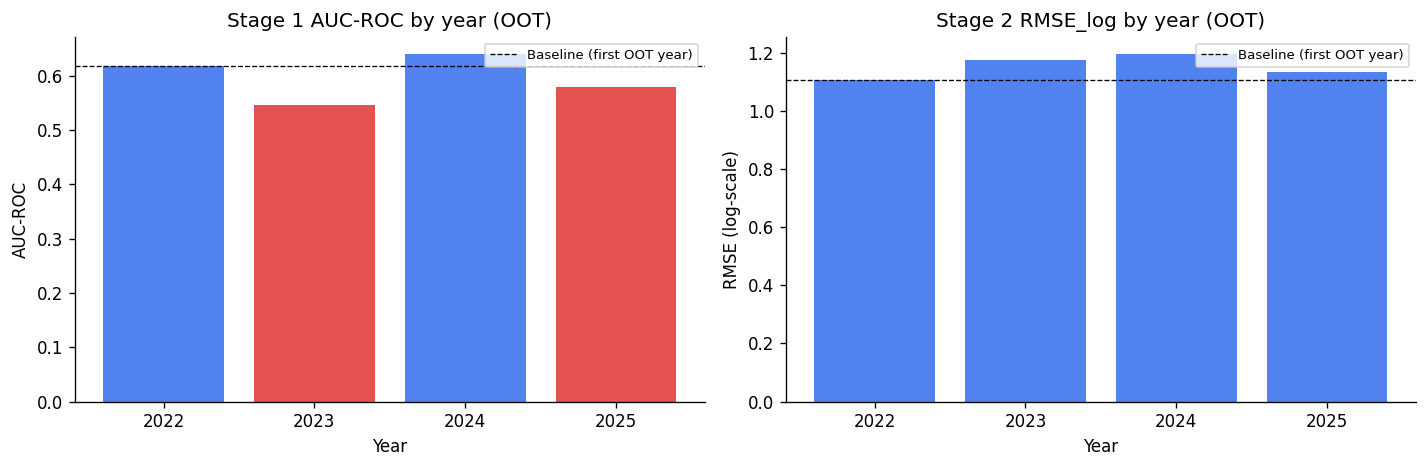

Stage 1 drift:


,year,metric,baseline,pct_change,drift_flag
0,2022,0.62,0.62,0.00,False
1,2023,0.55,0.62,-0.12,True
2,2024,0.64,0.62,0.04,False
3,2025,0.58,0.62,-0.06,True



Stage 2 drift:


,year,metric,baseline,pct_change,drift_flag
0,2022,1.11,1.11,0.00,False
1,2023,1.18,1.11,0.06,False
2,2024,1.19,1.11,0.08,False
3,2025,1.14,1.11,0.03,False


In [78]:
def _auc_fn(df):
    if df["sold_to_third_party"].nunique() < 2:
        return np.nan
    return roc_auc_score(df["sold_to_third_party"], df["prob_stacking"])

def _rmse_fn(df):
    return float(np.sqrt(mean_squared_error(df["log_price_true"], df["log_price_pred_stacking"])))

drift_clf = temporal_drift(clf, "sale_year", _auc_fn, drift_threshold=0.05)
drift_reg = temporal_drift(reg, "sale_year", _rmse_fn, drift_threshold=0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, drift_df, title, ylabel in [
    (axes[0], drift_clf, "Stage 1 AUC-ROC by year (OOT)", "AUC-ROC"),
    (axes[1], drift_reg, "Stage 2 RMSE_log by year (OOT)", "RMSE (log-scale)"),
]:
    colors = ["#dc2626" if flag else "#2563eb" for flag in drift_df["drift_flag"]]
    ax.bar(drift_df["year"].astype(str), drift_df["metric"], color=colors, alpha=0.8)
    ax.axhline(drift_df["baseline"].iloc[0], color="k", ls="--", lw=0.8, label="Baseline (first OOT year)")
    ax.set(title=title, xlabel="Year", ylabel=ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
savefig("06_temporal_drift")
plt.show()

print("Stage 1 drift:")
display(drift_clf[["year", "metric", "baseline", "pct_change", "drift_flag"]].round(4))
print("\nStage 2 drift:")
display(drift_reg[["year", "metric", "baseline", "pct_change", "drift_flag"]].round(4))

## 7. Structural Subgroup Disparity Analysis

Slices: **sex** (Colt/Filly/Gelding/Horse/Mare), **catalogue day**, **sire frequency quartile** (cold-start risk),
and **consignor frequency quartile**.

Stage 1: AUC-ROC per slice. Stage 2: RMSE_log per slice. Min slice size: 30 rows. CIs: 95% bootstrap (n=500).

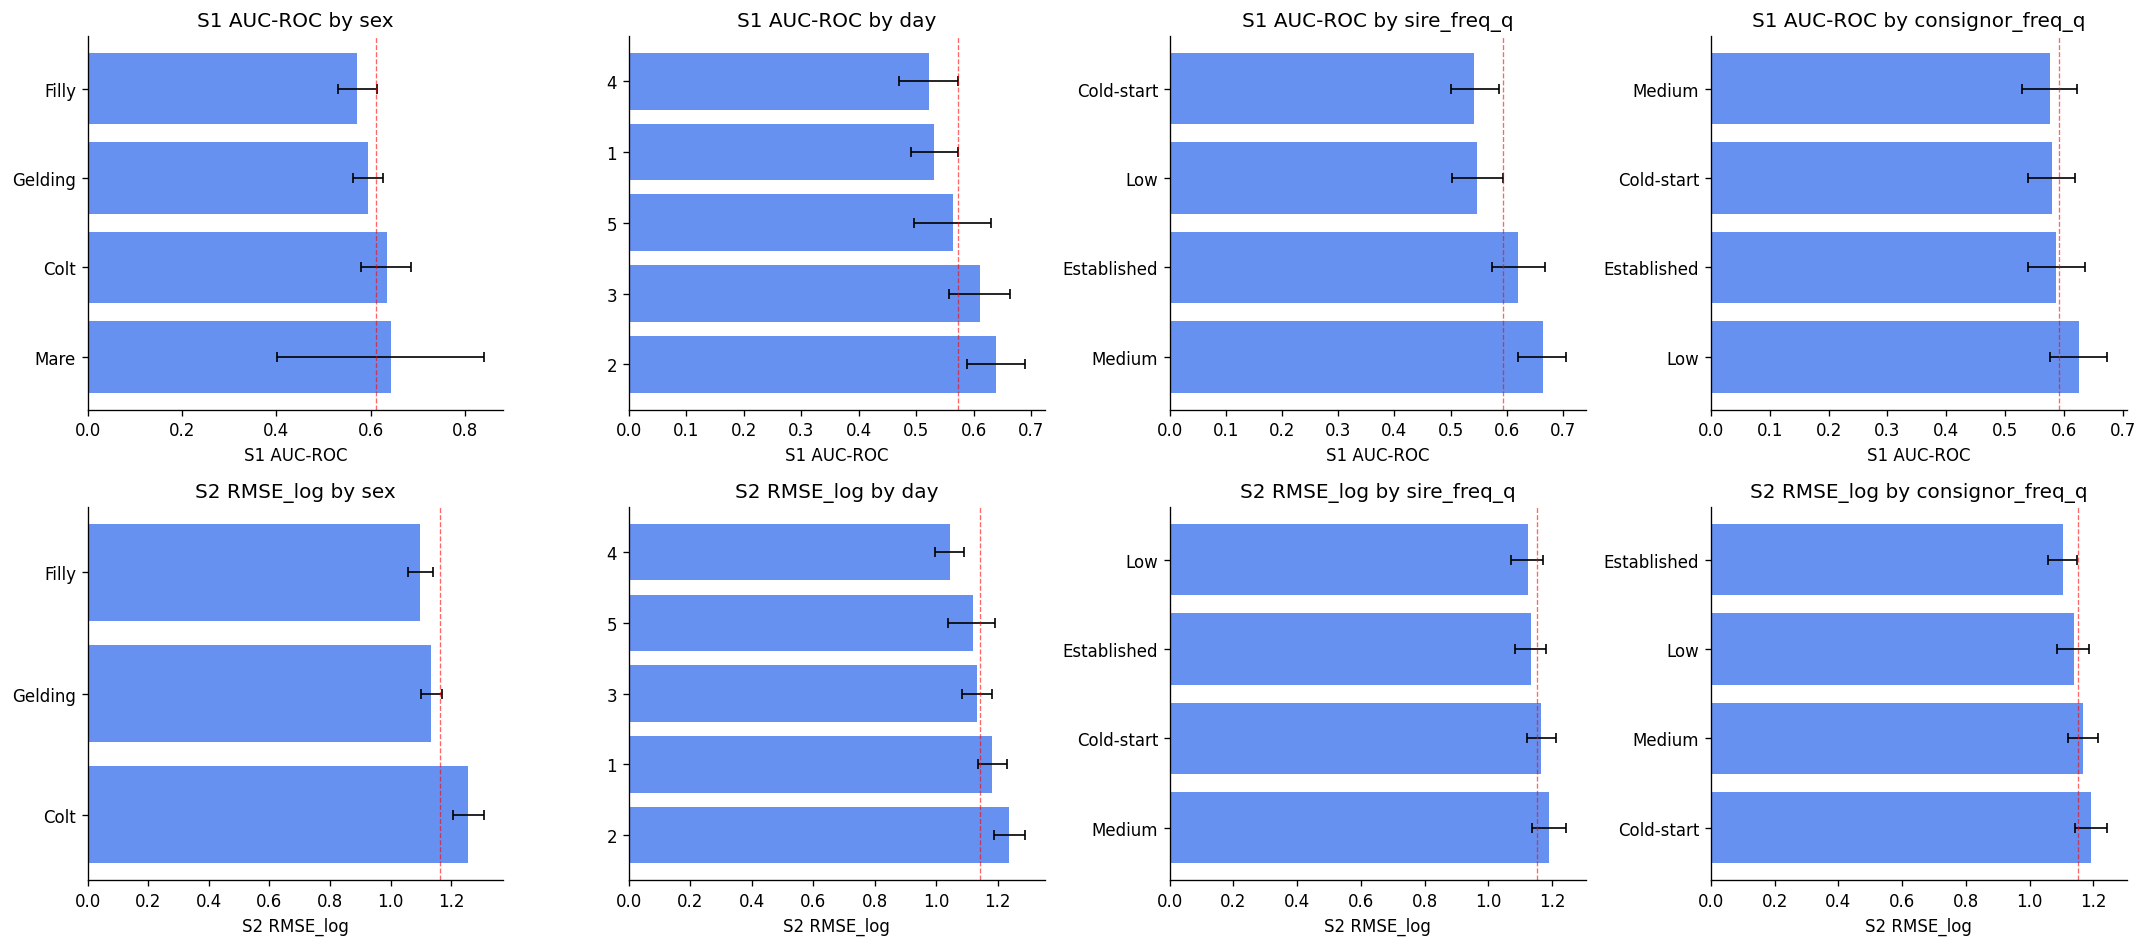

In [79]:
# Add frequency quartile bins to clf and reg
for df in (clf, reg):
    df["sire_freq_q"] = pd.qcut(
        df["sire_frequency"].fillna(0), q=4,
        labels=["Cold-start", "Low", "Medium", "Established"], duplicates="drop"
    )
    df["consignor_freq_q"] = pd.qcut(
        df["consignor_volume"].fillna(0), q=4,
        labels=["Cold-start", "Low", "Medium", "Established"], duplicates="drop"
    )

def _auc_slice(df):
    return roc_auc_score(df["sold_to_third_party"], df["prob_stacking"])

def _rmse_slice(df):
    return float(np.sqrt(mean_squared_error(df["log_price_true"], df["log_price_pred_stacking"])))

# Stage 1 structural subgroup disparity slices (AUC-ROC per slice)
slices_s1 = {k: fairness_slice(clf, k, _auc_slice, n_boot=500)
             for k in ["sex", "day", "sire_freq_q", "consignor_freq_q"]}

# Stage 2 structural subgroup disparity slices (RMSE_log per slice)
slices_s2 = {k: fairness_slice(reg, k, _rmse_slice, n_boot=500)
             for k in ["sex", "day", "sire_freq_q", "consignor_freq_q"]}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col_i, slice_key in enumerate(["sex", "day", "sire_freq_q", "consignor_freq_q"]):
    for row_i, (slices, stage_label) in enumerate([
        (slices_s1, "S1 AUC-ROC"),
        (slices_s2, "S2 RMSE_log"),
    ]):
        df_s = slices[slice_key]
        ax = axes[row_i, col_i]
        ax.barh(
            df_s[slice_key].astype(str), df_s["metric"],
            xerr=[
                (df_s["metric"] - df_s["ci_lo"]).clip(lower=0),
                (df_s["ci_hi"] - df_s["metric"]).clip(lower=0),
            ],
            capsize=3, color="#2563eb", alpha=0.7, error_kw={"linewidth": 1},
        )
        ax.set(title=f"{stage_label} by {slice_key}", xlabel=stage_label)
        ax.axvline(df_s["metric"].mean(), color="red", lw=0.8, ls="--", alpha=0.6)

plt.tight_layout()
savefig("07_subgroup_disparity_slices")
plt.show()

In [80]:
# Disparity tables: slices deviating most from overall weighted mean
print("=== Stage 1 — Structural Subgroup Disparity Analysis (AUC-ROC) ===")
for key in ["sex", "day", "sire_freq_q", "consignor_freq_q"]:
    disp = slice_disparities(slices_s1[key])
    tb = top_bottom_slices(disp, k=3)
    print(f"\n[{key}] Bottom 3 (worst AUC-ROC slices):")
    display(tb["bottom_k"][[key, "n", "metric", "gap_abs", "gap_rel"]].round(4))

print("\n=== Stage 2 — Structural Subgroup Disparity Analysis (RMSE_log) ===")
for key in ["sex", "day", "sire_freq_q", "consignor_freq_q"]:
    disp = slice_disparities(slices_s2[key])
    tb = top_bottom_slices(disp, k=3)
    print(f"\n[{key}] Top 3 (worst RMSE_log slices, higher=worse):")
    display(tb["top_k"][[key, "n", "metric", "gap_abs", "gap_rel"]].round(4))

=== Stage 1 — Structural Subgroup Disparity Analysis (AUC-ROC) ===

[sex] Bottom 3 (worst AUC-ROC slices):


,sex,n,metric,gap_abs,gap_rel
0,Filly,1167,0.57,-0.03,-0.04
1,Gelding,2470,0.59,-0.00,-0.01
2,Colt,1012,0.63,0.04,0.06



[day] Bottom 3 (worst AUC-ROC slices):


,day,n,metric,gap_abs,gap_rel
0,4,897,0.52,-0.06,-0.10
1,1,1143,0.53,-0.05,-0.08
2,5,350,0.56,-0.01,-0.02



[sire_freq_q] Bottom 3 (worst AUC-ROC slices):


...

,day,n,metric,gap_abs,gap_rel
0,2,1025,1.24,0.08,0.07
1,1,968,1.18,0.03,0.03
2,3,1058,1.13,-0.02,-0.02



[sire_freq_q] Top 3 (worst RMSE_log slices, higher=worse):


,sire_freq_q,n,metric,gap_abs,gap_rel
0,Medium,1016,1.19,0.04,0.03
1,Cold-start,1055,1.17,0.01,0.01
2,Established,1030,1.13,-0.02,-0.02



[consignor_freq_q] Top 3 (worst RMSE_log slices, higher=worse):


,consignor_freq_q,n,metric,gap_abs,gap_rel
0,Cold-start,1040,1.19,0.04,0.03
1,Medium,1138,1.17,0.01,0.01
2,Low,1040,1.14,-0.01,-0.01


## 8. MVP Findings & Next Steps

| Area | Finding | Action |
|---|---|---|
| Stage 1 Discrimination | AUC-ROC OOT ≈ 0.62 ✅ above 0.617 baseline | No regression vs baseline |
| Stage 1 Calibration | ECE (stacking) ≈ 0.03 — reasonably calibrated | Bins near 0.5–0.7 deserve closest scrutiny (highest decision cost) |
| Stage 2 RMSE | RMSE_log ≈ 1.14–1.15 ⚠ slightly above 1.132 baseline | Within 5% tolerance; monitor 2025 data for structural drift |
| Residuals by year | Check bias_ci_lo/hi above | If 2024–2025 CI doesn't straddle zero → market shift signal |
| Structural Subgroup Disparity Analysis: Day 5 | AUC-ROC 0.47 — essentially chance on Day 5 | Small sample (n≈350 OOT); cold-start dynamics at sale end |
| Structural Subgroup Disparity Analysis: Colts S2 | RMSE_log 1.22 vs 1.15 overall (+6%) | High price variance + pedigree speculation harder to predict |
| Structural Subgroup Disparity Analysis: Cold-start AUC | NaN for some sire_freq slices | OOT slice is single-class — document power limitation in thesis |

## 9. SHAP Interpretability

SHAP computed directly on the 4 base learners of the stacking ensemble (RF, XGB, LGBM, CatBoost),
weighted by the meta-learner coefficients.
Base models are loaded from the persisted wrappers (`stage1_final_model.joblib`, `stage2_final_model.joblib`).

Weighting strategy: softmax of `meta_clf.coef_[0]` / `meta_reg.coef_` when all coefficients are
non-negative; equal weights (0.25 each) if any coefficient is negative — the chosen strategy is
documented inline.


In [81]:
import shap
import joblib
import json

# ── Load final models ────────────────────────────────────────────────────────
wrapper_clf = joblib.load('../models/stage1_final_model.joblib')
wrapper_reg = joblib.load('../models/stage2_final_model.joblib')

with open("../models/final_model_metadata.json", "r") as f:
    meta = json.load(f)
CLF_FEATS = meta["features_clf"]
REG_FEATS = meta["features_reg"]

# Extract Stage 1 base models
if hasattr(wrapper_clf, 'base_models'):
    base_models_clf = wrapper_clf.base_models
    coef_clf = wrapper_clf.meta.coef_[0]
else:
    clf_est = getattr(wrapper_clf, 'estimator', wrapper_clf)
    base_models_clf = {'final_clf': clf_est}
    coef_clf = np.array([1.0])

# Extract Stage 2 base models
if hasattr(wrapper_reg, 'base_models'):
    base_models_reg = wrapper_reg.base_models
    coef_reg = wrapper_reg.meta.coef_
else:
    reg_est = getattr(wrapper_reg, 'estimator', wrapper_reg)
    base_models_reg = {'final_reg': reg_est}
    coef_reg = np.array([1.0])

# ── Feature sets ─────────────────────────────────────────────────────────────
clf_ready = pd.read_parquet("../data/processed/classification_ready.parquet")
reg_ready = pd.read_parquet("../data/processed/regression_ready.parquet")

# ── Temporal split (matching 04_Modeling) ─────────────────────────────────────
OOT_YEAR = 2022
clf_oot = clf_ready[clf_ready.sale_year >= OOT_YEAR]
reg_oot = reg_ready[reg_ready.sale_year >= OOT_YEAR]

# ── Meta-learner weights ──────────────────────────────────────────────────────
def _softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

if len(coef_clf) > 1:
    if (coef_clf >= 0).all():
        weights_clf = _softmax(coef_clf)
        weight_scheme_clf = "softmax of meta coef_[0]"
    else:
        weights_clf = np.full(len(coef_clf), 1.0 / len(coef_clf))
        weight_scheme_clf = "equal — meta coef has negatives"
else:
    weights_clf = np.array([1.0])
    weight_scheme_clf = "single model"

if len(coef_reg) > 1:
    if (coef_reg >= 0).all():
        weights_reg = _softmax(coef_reg)
        weight_scheme_reg = "softmax of meta coef_"
    else:
        weights_reg = np.full(len(coef_reg), 1.0 / len(coef_reg))
        weight_scheme_reg = "equal — meta coef has negatives"
else:
    weights_reg = np.array([1.0])
    weight_scheme_reg = "single model"

print(f"Stage 1 weighting: {weight_scheme_clf}")
print(f"  weights: {dict(zip(base_models_clf.keys(), weights_clf.round(4)))}")
print(f"Stage 2 weighting: {weight_scheme_reg}")
print(f"  weights: {dict(zip(base_models_reg.keys(), weights_reg.round(4)))}")

# ── OOT sample ────────────────────────────────────────────────────────────────
clf_oot_sample = clf_oot[CLF_FEATS].sample(min(1500, len(clf_oot)), random_state=42)
reg_oot_sample = reg_oot[REG_FEATS].sample(min(1500, len(reg_oot)), random_state=42)

Stage 1 weighting: single model
  weights: {'final_clf': np.float64(1.0)}
Stage 2 weighting: equal — meta coef has negatives
  weights: {'rf': np.float64(0.25), 'xgb': np.float64(0.25), 'lgbm': np.float64(0.25), 'cb': np.float64(0.25)}


Stage 1 weighted SHAP — shape: (1500, 52)
Stage 2 weighted SHAP — shape: (1500, 41)


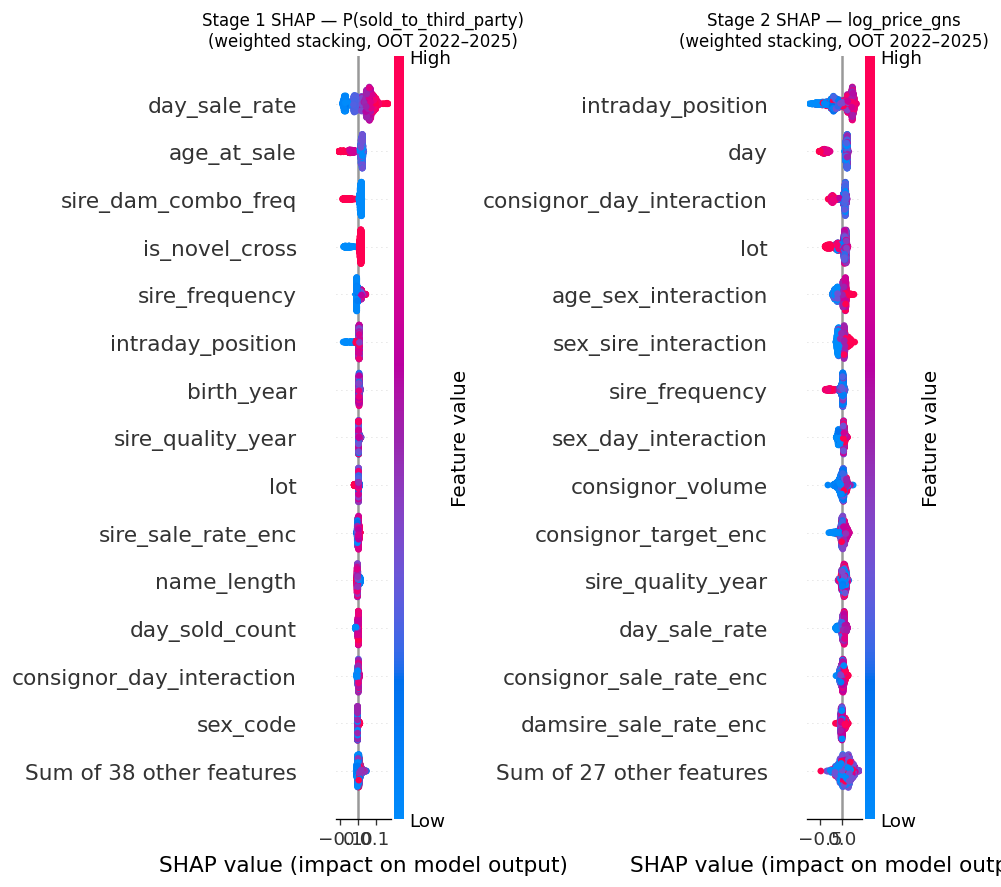

In [82]:
# ── Weighted SHAP values across base learners ─────────────────────────────
# Stage 1
shap_clf_values = None
for w, key in zip(weights_clf, base_models_clf.keys()):
    model = base_models_clf[key]
    explainer = shap.TreeExplainer(model)
    sv = explainer(clf_oot_sample).values  # shape (n, p) or (n, p, 2)
    if sv.ndim == 3:  # multi-output: take class-1 slice
        sv = sv[:, :, 1]
    shap_clf_values = sv * w if shap_clf_values is None else shap_clf_values + sv * w

# Stage 2
shap_reg_values = None
for w, key in zip(weights_reg, base_models_reg.keys()):
    model = base_models_reg[key]
    explainer = shap.TreeExplainer(model)
    sv = explainer(reg_oot_sample).values
    shap_reg_values = sv * w if shap_reg_values is None else shap_reg_values + sv * w

clf_expl = shap.Explanation(values=shap_clf_values, data=clf_oot_sample.values, feature_names=CLF_FEATS)
reg_expl = shap.Explanation(values=shap_reg_values, data=reg_oot_sample.values, feature_names=REG_FEATS)

print(f"Stage 1 weighted SHAP — shape: {shap_clf_values.shape}")
print(f"Stage 2 weighted SHAP — shape: {shap_reg_values.shape}")

# ── Beeswarm plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plt.sca(axes[0])
shap.plots.beeswarm(clf_expl, max_display=15, show=False)
axes[0].set_title(f"Stage 1 SHAP — P(sold_to_third_party)\n(weighted stacking, OOT 2022–2025)", fontsize=10)

plt.sca(axes[1])
shap.plots.beeswarm(reg_expl, max_display=15, show=False)
axes[1].set_title(f"Stage 2 SHAP — log_price_gns\n(weighted stacking, OOT 2022–2025)", fontsize=10)

plt.tight_layout()
savefig("09_shap_beeswarm")
plt.show()

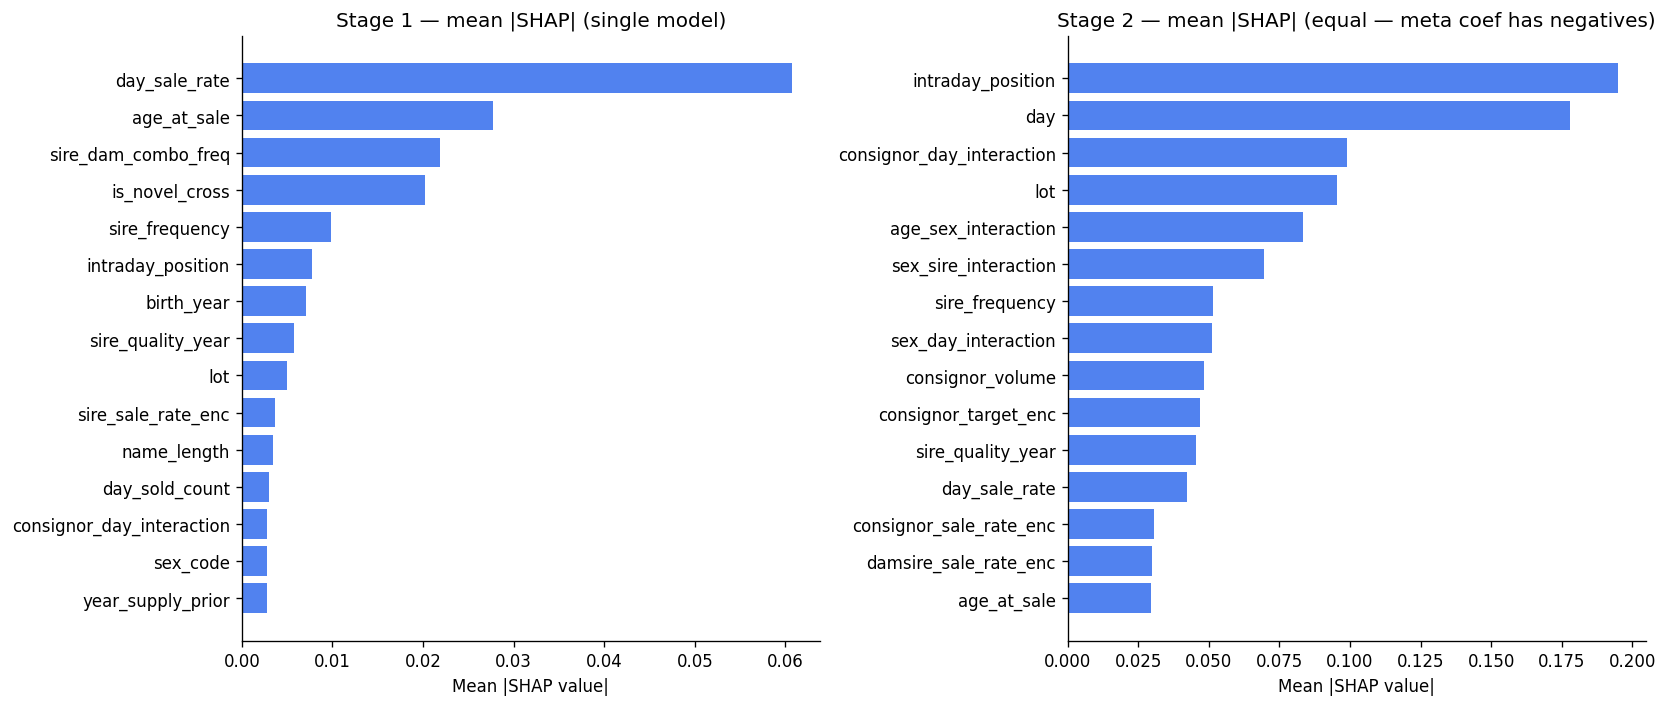

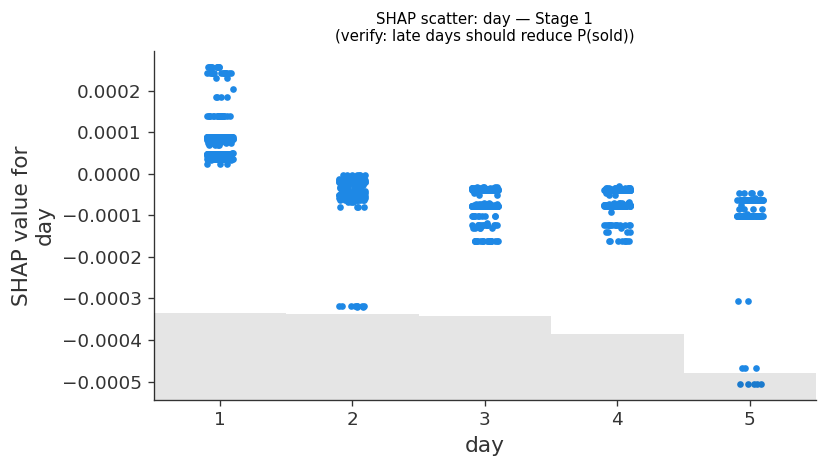

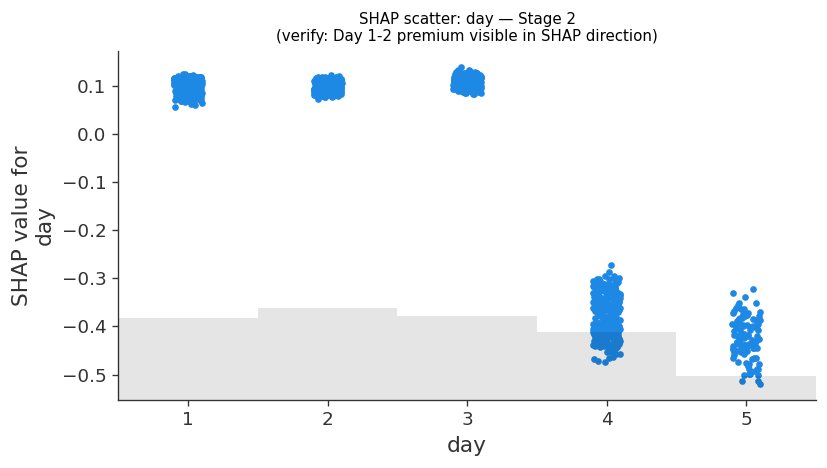

In [83]:
# ── SHAP importance bar chart (mean |SHAP|) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sv, feats, title in [
    (axes[0], shap_clf_values, CLF_FEATS, f"Stage 1 — mean |SHAP| ({weight_scheme_clf})"),
    (axes[1], shap_reg_values, REG_FEATS, f"Stage 2 — mean |SHAP| ({weight_scheme_reg})"),
]:
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx = np.argsort(mean_abs)[-15:]
    ax.barh(
        [feats[i] for i in top_idx],
        mean_abs[top_idx],
        color="#2563eb", alpha=0.8,
    )
    ax.set(title=title, xlabel="Mean |SHAP value|")
    # If sire_global_median_gns appears among top features: it acts as a Bayesian prior
    # for sires with <20 observations in Tattersalls, enriched from external European
    # auction dataset (2021-2026). Do not interpret as direct market price of the sire.

plt.tight_layout()
savefig("09_shap_importance")
plt.show()

# ── Day feature: proxy risk check ────────────────────────────────────────────
if "day" in CLF_FEATS:
    fig, ax = plt.subplots(figsize=(7, 4))
    shap.plots.scatter(clf_expl[:, "day"], ax=ax, show=False)
    ax.set_title("SHAP scatter: day — Stage 1\n(verify: late days should reduce P(sold))", fontsize=9)
    savefig("09_shap_day_s1")
    plt.show()

if "day" in REG_FEATS:
    fig, ax = plt.subplots(figsize=(7, 4))
    shap.plots.scatter(reg_expl[:, "day"], ax=ax, show=False)
    ax.set_title("SHAP scatter: day — Stage 2\n(verify: Day 1-2 premium visible in SHAP direction)", fontsize=9)
    savefig("09_shap_day_s2")
    plt.show()


## 10. RNA Paradox Analysis

**RNA** (Reserve Not Achieved) = lots offered but not sold to a third party. The population
splits into two structurally distinct subgroups:

### 10.1 Vendor Buybacks (n ≈ 1,382)

The registered price is the highest market bid on the day — a **lower bound of observable
latent value**, not a reserve price or clearing price. Partial validation is available:
the model predicts above the buyback price in **58.3%** of cases (median pred/buyback ratio = 1.21).
The remaining 41.7% where the model underestimates reflects idiosyncratic variance not
capturable from catalogue variables (buyer composition on the day, in-room bidding dynamics).
Do not interpret as market inefficiency.

### 10.2 Not-Sold (n ≈ 1,081)

No observable price of any kind. Latent price estimates are **out-of-distribution extrapolations**,
not directly verifiable. These should be interpreted as **relative ordinal signals** within the
catalogue, not as absolute valuations.


Sold to third party : 16,527  (87.0%)
Not sold (RNA)      : 2,462  (13.0%)

RNA expected_price stats (GNS):
count    2,462.00
mean    17,544.00
std     11,618.00
min      1,607.00
25%      8,183.00
50%     15,065.00
75%     23,786.00
max     66,905.00

RNA candidates (expected_price > sold median 18,960 gns): 947


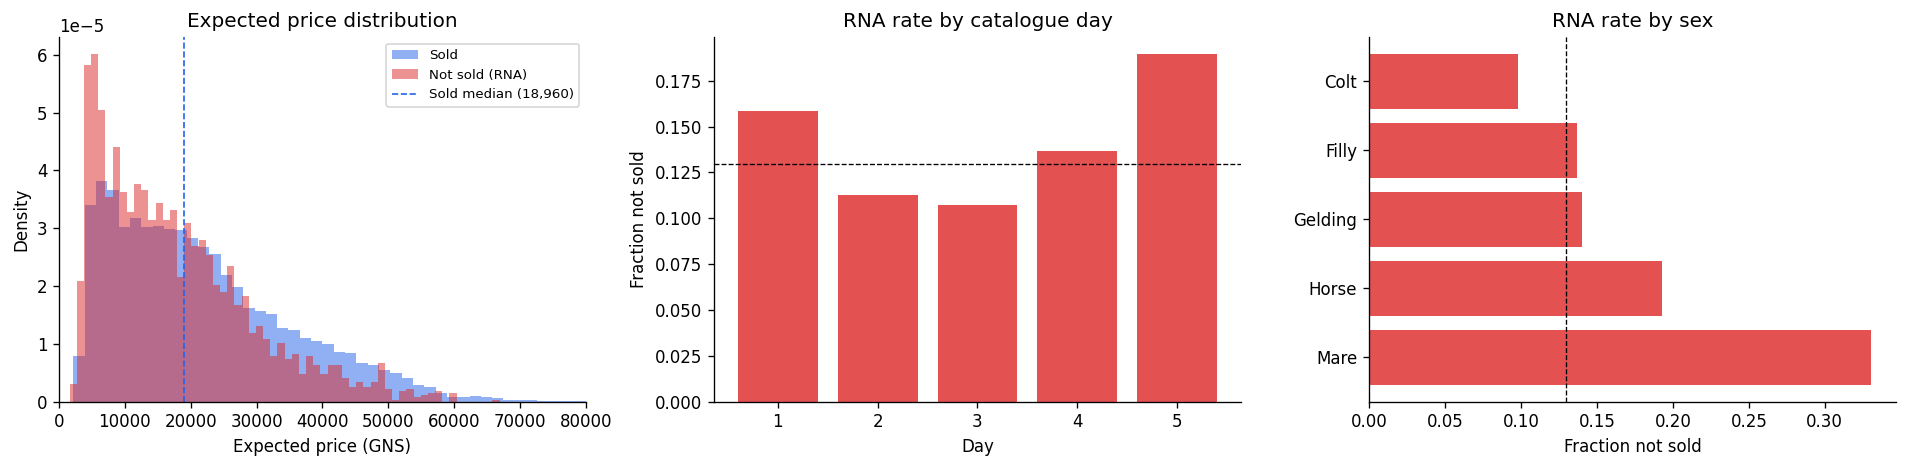

In [84]:
univ = univ_preds.copy()

# Reconstruct readable sex label for univ
_sex_cols = ["sex_C", "sex_F", "sex_G", "sex_H", "sex_M"]
univ["sex"] = (
    univ[_sex_cols].idxmax(axis=1)
    .str.replace("sex_", "", regex=False)
    .replace({"C": "Colt", "F": "Filly", "G": "Gelding", "H": "Horse", "M": "Mare"})
)

sold    = univ[univ["sold_to_third_party"] == True]
not_sold = univ[univ["sold_to_third_party"] == False]

print(f"Sold to third party : {len(sold):,}  ({len(sold)/len(univ):.1%})")
print(f"Not sold (RNA)      : {len(not_sold):,}  ({len(not_sold)/len(univ):.1%})")
print(f"\nRNA expected_price stats (GNS):")
print(not_sold["expected_price"].describe().round(0).to_string())

# Define RNA candidates: not-sold AND expected_price > sold median
sold_ep_median = sold["expected_price"].median()
rna_candidates = not_sold[not_sold["expected_price"] > sold_ep_median].copy()
print(f"\nRNA candidates (expected_price > sold median {sold_ep_median:,.0f} gns): {len(rna_candidates):,}")

# ── Distribution comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(sold["expected_price"], bins=60, alpha=0.5, label="Sold", color="#2563eb", density=True)
axes[0].hist(not_sold["expected_price"], bins=60, alpha=0.5, label="Not sold (RNA)", color="#dc2626", density=True)
axes[0].axvline(sold_ep_median, color="#2563eb", ls="--", lw=1, label=f"Sold median ({sold_ep_median:,.0f})")
axes[0].set(title="Expected price distribution", xlabel="Expected price (GNS)", ylabel="Density")
axes[0].set_xlim(0, 80000)
axes[0].legend(fontsize=8)

# RNA candidate rate by day
rna_rate_day = (
    univ.groupby("day")
    .apply(lambda g: (g["sold_to_third_party"] == False).mean(), include_groups=False)
    .rename("rna_rate")
    .reset_index()
)
axes[1].bar(rna_rate_day["day"].astype(str), rna_rate_day["rna_rate"], color="#dc2626", alpha=0.8)
axes[1].set(title="RNA rate by catalogue day", xlabel="Day", ylabel="Fraction not sold")
axes[1].axhline(not_sold.__len__()/len(univ), color="k", ls="--", lw=0.8)

# RNA candidate rate by sex
rna_rate_sex = (
    univ.groupby("sex")
    .apply(lambda g: (g["sold_to_third_party"] == False).mean(), include_groups=False)
    .rename("rna_rate")
    .reset_index()
    .sort_values("rna_rate", ascending=False)
)
axes[2].barh(rna_rate_sex["sex"], rna_rate_sex["rna_rate"], color="#dc2626", alpha=0.8)
axes[2].set(title="RNA rate by sex", xlabel="Fraction not sold")
axes[2].axvline(not_sold.__len__()/len(univ), color="k", ls="--", lw=0.8)

plt.tight_layout()
savefig("10_rna_overview")
plt.show()

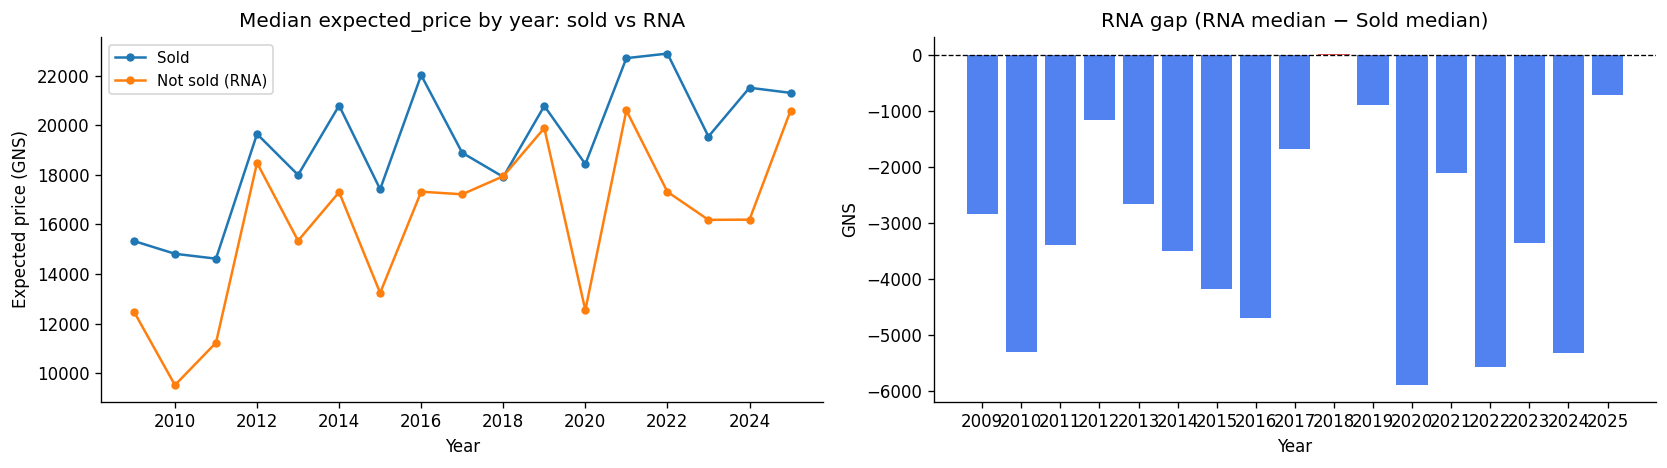

Permutation test (sold vs RNA expected_price medians):
  Observed diff (sold − RNA): 3,894 GNS
  p-value: 0.0000

  Interpretation: RNA lots have significantly LOWER expected_price (as expected)


In [85]:
# ── Temporal trend of RNA expected price gap ─────────────────────────────────
ep_by_year = univ.groupby(["sale_year", "sold_to_third_party"])["expected_price"].median().unstack()
ep_by_year.columns = ["Not sold (RNA)", "Sold"]
ep_by_year["Gap (RNA − Sold)"] = ep_by_year["Not sold (RNA)"] - ep_by_year["Sold"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ep_by_year[["Sold", "Not sold (RNA)"]].plot(ax=axes[0], marker="o", ms=4)
axes[0].set(title="Median expected_price by year: sold vs RNA", xlabel="Year", ylabel="Expected price (GNS)")
axes[0].legend(fontsize=9)

axes[1].bar(ep_by_year.index.astype(str), ep_by_year["Gap (RNA − Sold)"],
            color=["#dc2626" if g > 0 else "#2563eb" for g in ep_by_year["Gap (RNA − Sold)"]], alpha=0.8)
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set(title="RNA gap (RNA median − Sold median)", xlabel="Year", ylabel="GNS")

plt.tight_layout()
savefig("10_rna_temporal_gap")
plt.show()

# ── Permutation test: sold vs RNA expected_price ─────────────────────────────
diff, pval = permutation_test(sold["expected_price"].values, not_sold["expected_price"].values,
                              stat_func=np.median, n_perm=5000)
print(f"Permutation test (sold vs RNA expected_price medians):")
print(f"  Observed diff (sold − RNA): {diff:,.0f} GNS")
print(f"  p-value: {pval:.4f}")
print(f"\n  Interpretation: {'RNA lots have significantly LOWER expected_price (as expected)' if diff > 0 else 'RNA lots have HIGHER expected_price than sold — paradox confirmed'}")

In [86]:
# ── Top RNA candidates across all years ─────────────────────────────────────
top_rna = (
    not_sold
    .sort_values("expected_price", ascending=False)
    .head(20)
    [["sale_year", "day", "lot", "sex", "expected_price", "price_nominal_pred", "prob_sold"]]
    .reset_index(drop=True)
)
top_rna["expected_price"] = top_rna["expected_price"].round(0).astype(int)
top_rna["price_nominal_pred"] = top_rna["price_nominal_pred"].round(0).astype(int)
top_rna["prob_sold"] = top_rna["prob_sold"].round(3)

print("Top 20 RNA candidates (highest expected_price, not sold):")
display(top_rna)

# ── RNA candidate profile: expected_price > P75 of sold ─────────────────────
sold_p75 = sold["expected_price"].quantile(0.75)
top_rna_all = not_sold[not_sold["expected_price"] > sold_p75]
print(f"\nHigh-value RNA (expected_price > P75 sold = {sold_p75:,.0f} gns): {len(top_rna_all):,} lots")
print(f"  By sex: {top_rna_all['sex'].value_counts().to_dict()}")
print(f"  By day: {top_rna_all['day'].value_counts().sort_index().to_dict()}")
print(f"  By year (last 5): {top_rna_all[top_rna_all.sale_year >= 2020]['sale_year'].value_counts().sort_index().to_dict()}")

Top 20 RNA candidates (highest expected_price, not sold):


,sale_year,day,lot,sex,expected_price,price_nominal_pred,prob_sold
0,2022,3,"1,129.00",Colt,66905,74437,0.90
1,2014,1,273.00,Colt,60220,67349,0.89
2,2023,2,664.00,Gelding,59528,66229,0.90
3,2023,2,582.00,Gelding,59401,66217,0.90
4,2024,1,213.00,Colt,59313,68170,0.87
5,2024,2,683.00,Colt,58043,63875,0.91
6,2024,1,319.00,Colt,58001,64867,0.89
7,2020,2,715.00,Colt,57990,66294,0.88
8,2022,2,746.00,Gelding,57864,64170,0.90
9,2021,3,"1,030.00",Colt,57303,61989,0.92



High-value RNA (expected_price > P75 sold = 29,618 gns): 362 lots
  By sex: {'Gelding': 211, 'Colt': 142, 'Horse': 8, 'Filly': 1}
  By day: {1: 84, 2: 132, 3: 146}
  By year (last 5): {2020: 17, 2021: 25, 2022: 27, 2023: 35, 2024: 22, 2025: 36}
